In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from google.colab import drive
drive.mount('/content/drive')
    
!pip install spectral keras-cv-attention-models scikit-learn scipy -q
!pip install opencv-python-headless -q

print("✅ Done")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Done


In [ ]:
import os, re, time, gc, traceback, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spectral as spy
import cv2

from numpy.lib.stride_tricks import sliding_window_view
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                             cohen_kappa_score, confusion_matrix)
from sklearn.model_selection import train_test_split
from operator import truediv
from skimage.transform import resize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import (
    Layer, Input, Conv2D, Conv1D, Dense, Dropout,
    Flatten, Reshape, GlobalAveragePooling2D,
    BatchNormalization, Activation,
    Concatenate, Add, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from keras_cv_attention_models import attention_layers

warnings.filterwarnings("ignore")
print(f"✅ TF {tf.__version__}")
print(f"   GPUs visible: {tf.config.list_physical_devices('GPU')}")
print("   (empty = CPU-only mode ✅)")

✅ TF 2.20.0
   GPUs visible: []
   (empty = CPU-only mode ✅)


In [ ]:
# ── Dataset ───────────────────────────────────────────────────────────────────
HSID         = "PCBDataset"
Num_Classes  = 4
target_names = ["Others", "IC", "Capacitor", "Connector"]

# ── PCB indices ───────────────────────────────────────────────────────────────
pc_indices   = [0, 2, 17, 27, 52]

# ── Patch / PCA ───────────────────────────────────────────────────────────────
WS           = 8     # window size — matches reference notebook
k            = 15    # PCA components — matches reference notebook

# ── Splits ────────────────────────────────────────────────────────────────────
teRatio      = 0.50
vrRatio      = 0.50

# ── Class balancing ───────────────────────────────────────────────────────────
OTHERS_LIMIT = 6000

# ── Training ──────────────────────────────────────────────────────────────────
batch_size   = 56
epochs       = 100

# ── Paths ─────────────────────────────────────────────────────────────────────
HSI_BASE     = "/content/drive/MyDrive/PCBDataset/PCBDataset/HSI/"
MONOSEG_BASE = "/content/drive/MyDrive/PCBDataset/PCBDataset/HSI/Monoseg_masks/"

print(f"✅ Config | WS={WS} k={k} PCBs={pc_indices}")

✅ Config | WS=8 k=15 PCBs=[0, 2, 17, 27, 52]


In [ ]:
def ClassificationReports(TeC, Te_Pre, target_names):
    """Metrics for disjoint samples — always uses all Num_Classes labels."""
    true   = np.argmax(TeC, axis=1) + 1          # 1-based
    labels = list(range(1, len(target_names) + 1)) # [1, 2, 3, 4]

    report = classification_report(
        true, Te_Pre,
        labels      = labels,
        target_names= target_names,
        zero_division= 0)

    oa   = accuracy_score(true, Te_Pre)
    conf = confusion_matrix(true, Te_Pre, labels=labels)
    diag = np.diag(conf)
    rs   = np.sum(conf, axis=1)
    per  = np.nan_to_num(truediv(diag, rs))
    aa   = np.mean(per)
    kappa= cohen_kappa_score(true, Te_Pre, labels=labels)

    return (report, conf,
            round(oa*100, 4), per*100,
            round(aa*100, 4), round(kappa*100, 4))


def ClassificationReports_HSI(GTA, T_Predicted, target_names):
    """Metrics for complete HSI — always uses all Num_Classes labels."""
    true   = np.argmax(GTA, axis=1)              # 0-based
    pred   = np.argmax(T_Predicted, axis=1)
    labels = list(range(len(target_names)))       # [0, 1, 2, 3]

    report = classification_report(
        true, pred,
        labels      = labels,
        target_names= target_names,
        zero_division= 0)

    oa   = accuracy_score(true, pred)
    conf = confusion_matrix(true, pred, labels=labels)
    diag = np.diag(conf)
    rs   = np.sum(conf, axis=1)
    per  = np.nan_to_num(truediv(diag, rs))
    aa   = np.mean(per)
    kappa= cohen_kappa_score(true, pred, labels=labels)

    return (report, conf,
            round(oa*100, 4), per*100,
            round(aa*100, 4), round(kappa*100, 4))

In [ ]:
# ── Shared helper ─────────────────────────────────────────────────────────────
def _bn():
    return BatchNormalization(
        gamma_initializer="ones",
        beta_initializer="zeros",
        moving_mean_initializer="zeros",
        moving_variance_initializer="ones")


# ══════════════════════════════════════════════════════════════════════════════
#  MODEL 1 — GaborMamba
#  Gabor texture extraction → spatial token generation →
#  feature gating → dilated Conv1D temporal encoder → classifier
# ══════════════════════════════════════════════════════════════════════════════

class GaborLayer(Layer):
    """Fixed Gabor filter bank — weights set from numpy, no GPU random ops."""

    def __init__(self, filters=6, kernel_size=5, **kwargs):
        super().__init__(**kwargs)
        self.filters     = filters
        self.kernel_size = kernel_size

    def build(self, input_shape):
        in_ch    = int(input_shape[-1])
        self.gks = []
        for theta in np.linspace(0, np.pi, self.filters):
            kernel = cv2.getGaborKernel(
                (self.kernel_size, self.kernel_size),
                sigma=2.0, theta=theta, lambd=5.0, gamma=0.5,
                ktype=cv2.CV_32F)
            kernel -= kernel.mean()
            s = kernel.std()
            if s > 1e-8:
                kernel /= s
            # depthwise kernel: (kH, kW, in_ch, 1)
            kernel = kernel[:, :, np.newaxis, np.newaxis]
            kernel = np.repeat(kernel, in_ch, axis=2)
            w = self.add_weight(
                name=f"gabor_{theta:.3f}",
                shape=kernel.shape,
                initializer=tf.constant_initializer(kernel),
                trainable=False,
                dtype=tf.float32)
            self.gks.append(w)
        super().build(input_shape)

    def call(self, x):
        return tf.concat([
            tf.nn.depthwise_conv2d(x, k, strides=[1, 1, 1, 1], padding="SAME")
            for k in self.gks], axis=-1)


class GaborTokenGen(Layer):
    def __init__(self, out_ch, **kwargs):
        super().__init__(**kwargs)
        self.gabor = GaborLayer(filters=6, kernel_size=5)
        self.conv  = Conv2D(out_ch, 1, activation="relu",
                            kernel_initializer="he_uniform")
        self.bn    = _bn()

    def call(self, x, training=False):
        return self.bn(self.conv(self.gabor(x)), training=training)


class GaborFeatureGate(Layer):
    def __init__(self, out_ch, **kwargs):
        super().__init__(**kwargs)
        self.fc   = Dense(out_ch, kernel_initializer="glorot_uniform")
        self.sigm = Activation("sigmoid")

    def call(self, tokens, center):
        g = self.sigm(self.fc(center))              # (B, C)
        return tokens * g[:, tf.newaxis, tf.newaxis, :]


class Conv1DTemporalEncoder(Layer):
    """Dilated causal Conv1D — no RNN, no SeedGenerator, no GPU-at-init."""

    def __init__(self, state_dim, **kwargs):
        super().__init__(**kwargs)
        def _c(ch, dil):
            return Conv1D(ch, 3, padding="causal",
                          dilation_rate=dil, activation="relu",
                          kernel_initializer="he_uniform")
        self.c1  = _c(state_dim,      1)
        self.c2  = _c(state_dim,      2)
        self.c3  = _c(state_dim,      4)
        self.bn1 = _bn(); self.bn2 = _bn(); self.bn3 = _bn()
        self.proj = Dense(state_dim, activation="relu",
                          kernel_initializer="he_uniform")

    def call(self, x, training=False):
        s   = tf.shape(x)
        seq = tf.reshape(x, [s[0], s[1] * s[2], s[3]])  # (B, HW, C)
        h1  = self.bn1(self.c1(seq), training=training)
        h2  = self.bn2(self.c2(h1),  training=training)
        h3  = self.bn3(self.c3(h1 + h2), training=training)
        return self.proj(tf.reduce_mean(h3, axis=1))     # (B, state_dim)


class GaborMambaModel(tf.keras.Model):
    def __init__(self, out_ch=64, state_dim=128,
                 num_classes=4, **kwargs):
        super().__init__(**kwargs)
        self.token_gen = GaborTokenGen(out_ch)
        self.gate      = GaborFeatureGate(out_ch)
        self.encoder   = Conv1DTemporalEncoder(state_dim)
        self.d1   = Dense(256, activation="relu",
                          kernel_initializer="he_uniform")
        self.bn1  = _bn()
        self.d2   = Dense(128, activation="relu",
                          kernel_initializer="he_uniform")
        self.bn2  = _bn()
        self.drop = Dropout(0.4)
        self.out  = Dense(num_classes, activation="softmax")

    def call(self, x, training=False):
        tokens = self.token_gen(x, training=training)
        h      = tf.shape(tokens)[1]
        w      = tf.shape(tokens)[2]
        center = tokens[:, h // 2, w // 2, :]
        enh    = self.gate(tokens, center)
        state  = self.encoder(enh, training=training)
        feat   = self.drop(
            self.bn1(self.d1(state), training=training),
            training=training)
        feat   = self.bn2(self.d2(feat), training=training)
        return self.out(feat)


def GaborMamba(WS, k, Num_Classes):
    m = GaborMambaModel(out_ch=64, state_dim=128,
                        num_classes=Num_Classes, name="GaborMamba")
    m.build((None, WS, WS, k))
    return m


# ══════════════════════════════════════════════════════════════════════════════
#  MODEL 2 — CNN2D + AttentionGCN  (your code from reference notebook)
# ══════════════════════════════════════════════════════════════════════════════

def CNN2D_AttGCN(WS, k, Num_Classes, alpha=0.5):
    inp = Input((WS, WS, k), name="input")

    # ── CNN2D branch ──────────────────────────────────────────────────────
    c = Conv2D(8,   3, padding='same', activation='relu')(inp);  c = _bn()(c)
    c = Conv2D(16,  3, padding='same', activation='relu')(c);    c = _bn()(c)
    c = Conv2D(32,  3, padding='same', activation='relu')(c);    c = _bn()(c)
    c = Conv2D(64,  3, padding='same', activation='relu')(c);    c = _bn()(c)
    c = Flatten()(c)
    cnn_feat = Dense(256, activation='relu')(c)

    # ── AttentionGCN branch ───────────────────────────────────────────────
    g1  = Conv2D(8, 1, activation='relu',
                 kernel_regularizer=regularizers.l2(5e-4))(inp)
    nn  = attention_layers.cot_attention(g1, kernel_size=3)

    # GloRe graph reasoning (matches reference AttentionGCN exactly)
    gt  = Reshape((8, WS * WS))(g1)
    sq  = Conv1D(16, 1, activation='relu')(gt)
    sq  = Reshape((8, 16))(sq)
    gc  = Conv1D(64, 1, activation='relu')(sq)
    gc  = Reshape((8, 64))(gc)
    us  = Conv1D(64, 1, activation='relu')(gc)
    us  = Reshape((64, 8))(us)
    gl  = Reshape((8, WS, WS))(us)

    gb  = Concatenate()([g1, gl, nn])
    g2  = Conv2D(32, 1, activation='relu')(gb);  g2 = _bn()(g2)
    g3  = Conv2D(64, 3, activation='relu')(g2);  g3 = _bn()(g3)
    g4  = Conv2D(128,1, activation='relu')(g3);  g4 = _bn()(g4)
    g4  = GlobalAveragePooling2D()(g4)
    gcn_feat = Dense(256, activation='relu')(g4)

    # ── Alpha-weighted fusion ──────────────────────────────────────────────
    fused = Add()([
        Lambda(lambda x: alpha * x)(cnn_feat),
        Lambda(lambda x: (1 - alpha) * x)(gcn_feat)
    ])

    # ── Classifier ────────────────────────────────────────────────────────
    x = Dense(128, activation='relu')(fused); x = Dropout(0.4)(x)
    x = Dense(64,  activation='relu')(x);     x = Dropout(0.3)(x)
    out = Dense(Num_Classes, activation='softmax')(x)

    return Model(inp, out, name="CNN2D_AttGCN")


# ── Model registry ────────────────────────────────────────────────────────────
model_fns = [
    ("GaborMamba",   GaborMamba),
    ("CNN2D_AttGCN", CNN2D_AttGCN),
]

print("✅ GaborMamba + CNN2D_AttGCN defined")

✅ GaborMamba + CNN2D_AttGCN defined


In [ ]:
def train_and_evaluate_model(model_fn, model_name_str,
                              Tr, TrC, Va, VaC, Te, TeC,
                              CRDHSI, GT, flattened,
                              val_matrix,  VaInd,
                              test_matrix, TeInd,
                              pcb_tag):

    print(f"\n  {'─'*55}")
    print(f"  Model : {model_name_str}  |  {pcb_tag}")
    print(f"  {'─'*55}")

    # ── Build ─────────────────────────────────────────────────────────────
    model = model_fn(WS, k, Num_Classes)
    model.summary(line_length=80)

    model.compile(
        loss      = "categorical_crossentropy",
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
        metrics   = ["accuracy"])

    # ── Train  (NO early stopping — runs full epochs) ─────────────────────
    t0 = time.perf_counter()
    history = model.fit(
        Tr, TrC,
        batch_size      = batch_size,
        epochs          = epochs,
        validation_data = (Va, VaC),
        verbose         = 1)
    Tr_Time = time.perf_counter() - t0
    params  = model.count_params()
    print(f"\n  Training time : {Tr_Time:.1f}s  |  Params: {params:,}")

    # ── Validation prediction ──────────────────────────────────────────────
    t0     = time.perf_counter()
    Va_Pre = PreModel(Va, model)
    Va_Time= time.perf_counter() - t0

    # ── Test prediction ────────────────────────────────────────────────────
    t0     = time.perf_counter()
    Te_Pre = PreModel(Te, model)
    Te_Time= time.perf_counter() - t0

    # ── Full-HSI prediction ────────────────────────────────────────────────
    print("  Building full-HSI map …")
    t0       = time.perf_counter()
    T_labels = GT_Plot(CRDHSI, GT, model, WS, k).astype(int)
    T_Time   = time.perf_counter() - t0

    # ── Spatial label maps ─────────────────────────────────────────────────
    Va_labels = Tranform_Labels(val_matrix,  VaInd, Va_Pre)
    Te_labels = Tranform_Labels(test_matrix, TeInd, Te_Pre)

    # ── One-hot encode GT + predictions ───────────────────────────────────
    GTA         = Convert(GT, flattened).astype(int)
    T_Predicted = Convert(GT, T_labels).astype(int)

    # ── Metrics ───────────────────────────────────────────────────────────
    Va_cls, Va_Conf, Va_OA, Va_Per, Va_AA, Va_Kappa = \
        ClassificationReports(VaC, Va_Pre, target_names)
    Te_cls, Te_Conf, Te_OA, Te_Per, Te_AA, Te_Kappa = \
        ClassificationReports(TeC, Te_Pre, target_names)
    T_cls, T_Conf, T_OA, T_Per, T_AA, T_Kappa = \
        ClassificationReports_HSI(GTA, T_Predicted, target_names)

    print(f"\n  ── Validation ──")
    print(f"  OA={Va_OA:.2f}%  AA={Va_AA:.2f}%  Kappa={Va_Kappa:.2f}%")
    print(Va_cls)

    print(f"  ── Test ──")
    print(f"  OA={Te_OA:.2f}%  AA={Te_AA:.2f}%  Kappa={Te_Kappa:.2f}%")
    print(Te_cls)

    print(f"  ── Full HSI ──")
    print(f"  OA={T_OA:.2f}%  AA={T_AA:.2f}%  Kappa={T_Kappa:.2f}%")
    print(T_cls)

    # ── Save CSV ──────────────────────────────────────────────────────────
    csv_path = f"{HSID}_{pcb_tag}_{model_name_str}_results.csv"
    CSVResults(csv_path,
               Va_cls, Va_Conf, Tr_Time, Va_Time, Te_Time, T_Time,
               Va_Kappa, Va_OA, Va_AA, Va_Per,
               Te_cls, Te_Conf, Te_Kappa, Te_OA, Te_AA, Te_Per,
               T_cls, T_Conf, T_Kappa, T_OA, T_AA, T_Per, params)
    print(f"  ✅ CSV : {csv_path}")

    # ── Prediction map plot ───────────────────────────────────────────────
    cmap = 'nipy_spectral'
    fig, axs = plt.subplots(1, 3, figsize=(14, 5))
    for ax, img, title in [
        (axs[0], Va_labels, f'Validation\nKappa={Va_Kappa:.2f}%'),
        (axs[1], Te_labels, f'Test\nKappa={Te_Kappa:.2f}%'),
        (axs[2], T_labels,  f'Full HSI\nKappa={T_Kappa:.2f}%'),
    ]:
        ax.imshow(img, cmap=cmap, interpolation='nearest')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f"{model_name_str}  |  {pcb_tag}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f"{HSID}_{pcb_tag}_{model_name_str}_Predicted_GTs.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"  ✅ Map : {fname}")

    # ── Confusion matrix ──────────────────────────────────────────────────
    cn  = T_Conf.astype(float) / T_Conf.sum(axis=1, keepdims=True).clip(1)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cn, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(target_names)))
    ax.set_xticklabels(target_names, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(target_names)))
    ax.set_yticklabels(target_names, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Full-HSI Confusion Matrix\n"
                 f"{model_name_str}  {pcb_tag}", fontweight='bold')
    for i in range(len(target_names)):
        for j in range(len(target_names)):
            ax.text(j, i, f"{cn[i,j]:.2f}",
                    ha='center', va='center', fontsize=9,
                    color='white' if cn[i,j] > 0.6 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fname = f"{HSID}_{pcb_tag}_{model_name_str}_confusion.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"  ✅ CM  : {fname}")

    return history, {
        'model'  : model_name_str,
        'Va_OA'  : Va_OA,  'Va_AA'  : Va_AA,  'Va_K'  : Va_Kappa,
        'Te_OA'  : Te_OA,  'Te_AA'  : Te_AA,  'Te_K'  : Te_Kappa,
        'HSI_OA' : T_OA,   'HSI_AA' : T_AA,   'HSI_K' : T_Kappa,
        'Params' : params,
    }

print("✅ train_and_evaluate_model ready (no early stopping)")

✅ train_and_evaluate_model ready (no early stopping)



PCB 0
  Loading: pcb1
  HSI=(272, 499, 224) GT=(272, 499) labels=[0 1 2 3]
  PCA 15 components


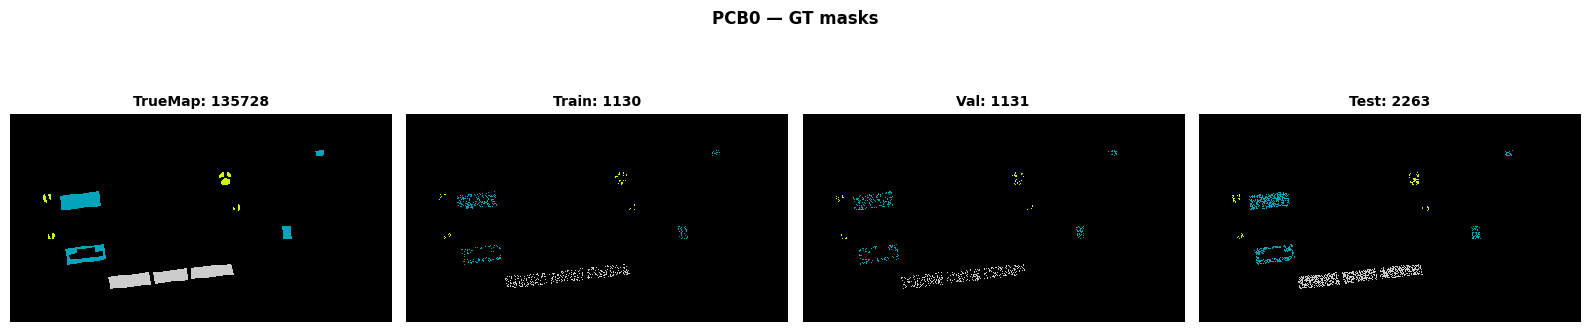

  ✅ GT mask saved: PCBDataset_PCB0_GT_masks.png
  ✅ Tr:1130  Va:1131  Te:2263
   Training  Validation  Test
1       475         476   951
2        73          73   147
3       582         582  1165

PCB 2
  Loading: pcb3
  HSI=(401, 556, 224) GT=(401, 556) labels=[0 1 2 3]
  PCA 15 components


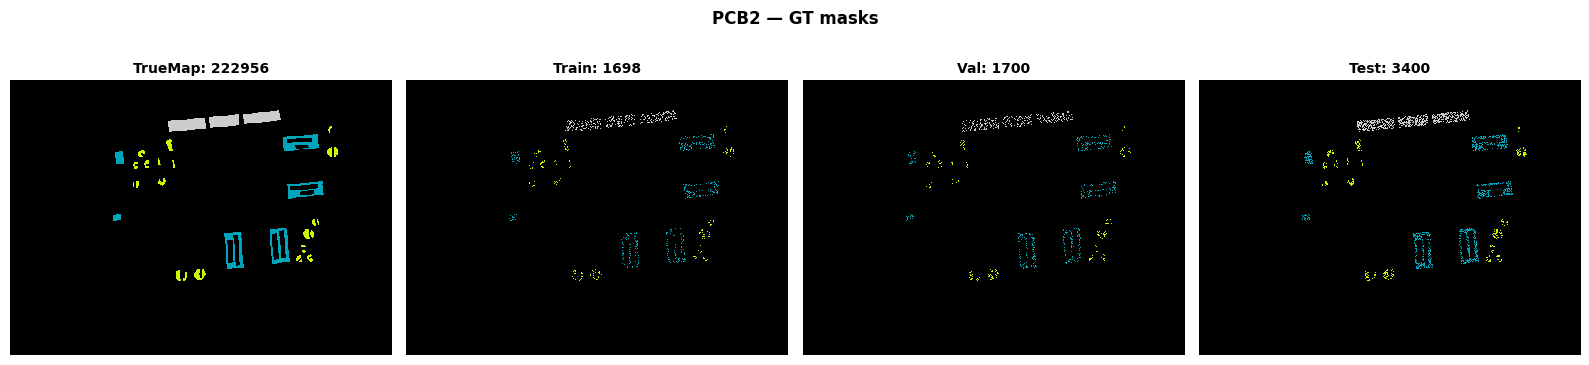

  ✅ GT mask saved: PCBDataset_PCB2_GT_masks.png
  ✅ Tr:1698  Va:1700  Te:3400
   Training  Validation  Test
1       783         784  1568
2       329         330   659
3       586         586  1173

PCB 17
  Loading: pcb18
  HSI=(370, 560, 224) GT=(370, 560) labels=[0 1 2 3]
  PCA 15 components


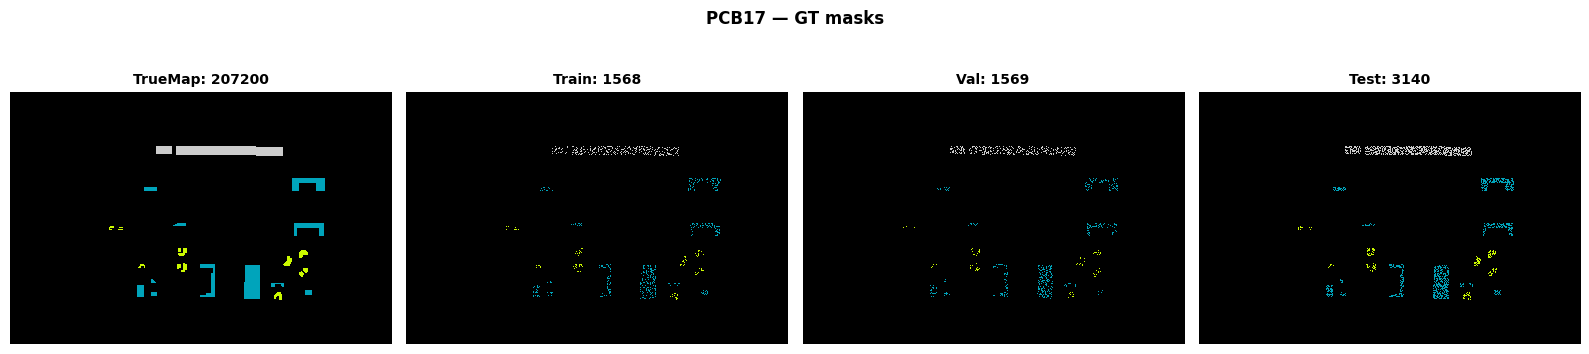

  ✅ GT mask saved: PCBDataset_PCB17_GT_masks.png
  ✅ Tr:1568  Va:1569  Te:3140
   Training  Validation  Test
1       807         807  1615
2       179         180   360
3       582         582  1165

PCB 27
  Loading: pcb28
  HSI=(367, 669, 224) GT=(367, 669) labels=[0 1 2 3]
  PCA 15 components


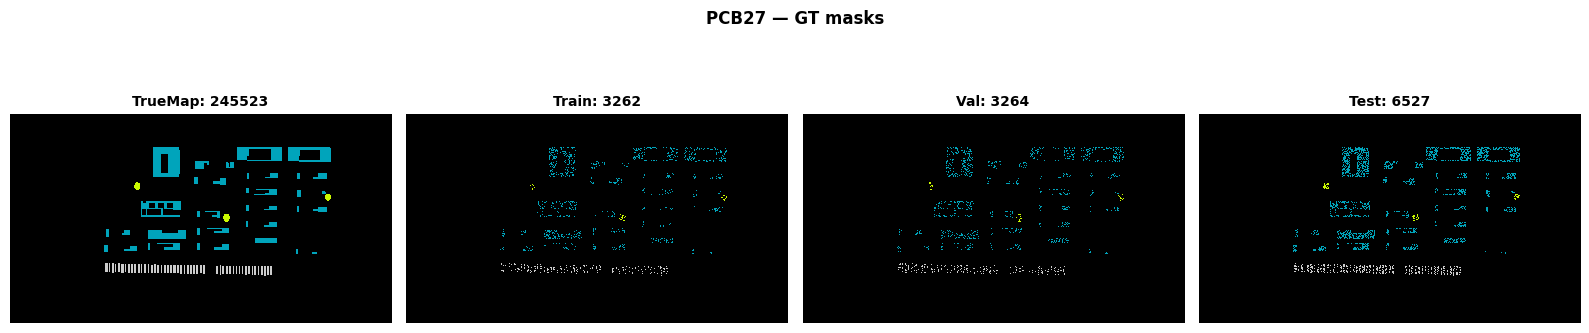

  ✅ GT mask saved: PCBDataset_PCB27_GT_masks.png
  ✅ Tr:3262  Va:3264  Te:6527
   Training  Validation  Test
1      2614        2615  5230
2        86          86   172
3       562         563  1125

PCB 52
  Loading: pcb53
  HSI=(399, 520, 224) GT=(399, 520) labels=[0 1 2 3]
  PCA 15 components


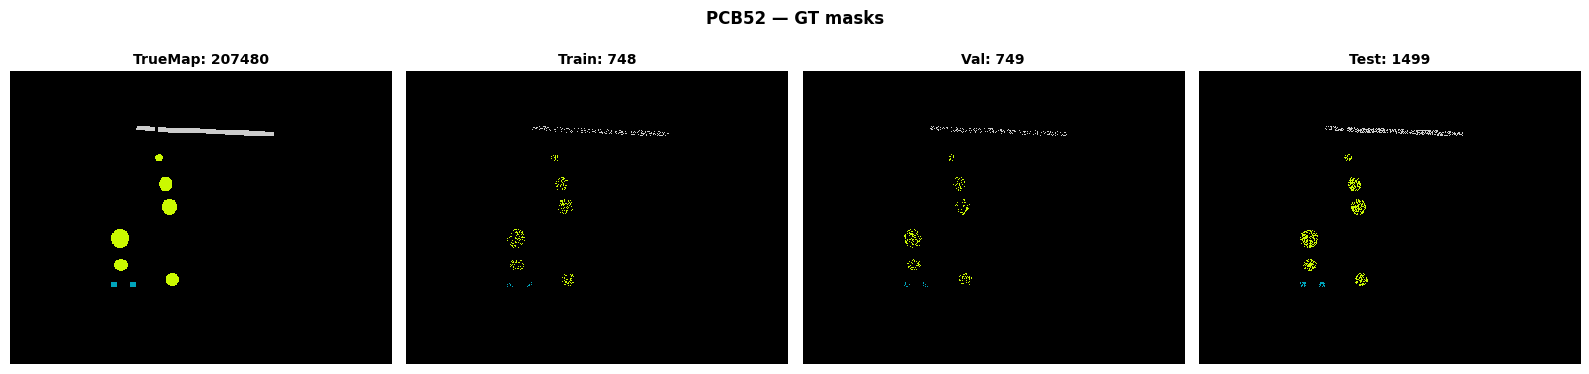

  ✅ GT mask saved: PCBDataset_PCB52_GT_masks.png
  ✅ Tr:748  Va:749  Te:1499
   Training  Validation  Test
1        24          24    49
2       431         431   862
3       293         294   588

✅ 5 PCB(s) preprocessed


In [ ]:
pcb_data_list = []

for pcb_index in pc_indices:
    print(f"\n{'='*60}\nPCB {pcb_index}")
    try:
        HSI, GT = LoadHSIData(pcb_index)

        if HSI.shape[:2] != GT.shape[:2]:
            GT = resize(GT, HSI.shape[:2], order=0,
                        preserve_range=True,
                        anti_aliasing=False).astype(np.int32)

        # PCA + normalise
        RDHSI = normalize(DLMethod(HSI, NC=k))
        del HSI; gc.collect()

        # Patch extraction (all pixels including zeros)
        CRDHSI, CGT = ImageCubes(RDHSI, GT, WS=WS, removeZeroLabels=False)

        # ── Split logic — matches reference notebook exactly ──────────────
        num_rows, num_cols = GT.shape
        flattened          = GT.flatten()
        unique_values      = np.unique(flattened)
        unique_values      = unique_values[unique_values != 0]

        np.random.seed(42)
        Samples = pd.DataFrame(columns=['Training', 'Validation', 'Test'])
        TrInd, VaInd, TeInd = [], [], []

        for value in unique_values:
            cls_idx = np.where(flattened == value)[0]
            if value == 0 and len(cls_idx) > OTHERS_LIMIT:
                cls_idx = np.random.choice(
                    cls_idx, OTHERS_LIMIT, replace=False)

            tr_idx, te_idx = train_test_split(
                cls_idx, test_size=teRatio, random_state=42)
            tr_idx, va_idx = train_test_split(
                tr_idx, test_size=vrRatio, random_state=42)

            Samples.loc[value] = [len(tr_idx), len(va_idx), len(te_idx)]
            TrInd.extend(tr_idx)
            VaInd.extend(va_idx)
            TeInd.extend(te_idx)

        # Spatial indicator matrices
        train_matrix = np.zeros_like(GT); train_matrix.flat[TrInd] = 1
        val_matrix   = np.zeros_like(GT); val_matrix.flat[VaInd]   = 1
        test_matrix  = np.zeros_like(GT); test_matrix.flat[TeInd]  = 1

        # Labels (0-based for to_categorical)
        TRC = CGT[TrInd] - 1
        VAC = CGT[VaInd] - 1
        TEC = CGT[TeInd] - 1

        Tr  = CRDHSI[TrInd];  TrC = to_categorical(TRC, Num_Classes)
        Va  = CRDHSI[VaInd];  VaC = to_categorical(VAC, Num_Classes)
        Te  = CRDHSI[TeInd];  TeC = to_categorical(TEC, Num_Classes)

        # ── Plot GT masks (matches reference) ─────────────────────────────
        TRC_labels = Tranform_Labels(train_matrix, TrInd, TRC + 1)
        VAC_labels = Tranform_Labels(val_matrix,   VaInd, VAC + 1)
        TEC_labels = Tranform_Labels(test_matrix,  TeInd, TEC + 1)

        cmap = 'nipy_spectral'
        fig, axs = plt.subplots(1, 4, figsize=(16, 4))
        for ax, img, title in [
            (axs[0], GT,         f'TrueMap: {num_rows*num_cols}'),
            (axs[1], TRC_labels, f'Train: {len(TrInd)}'),
            (axs[2], VAC_labels, f'Val: {len(VaInd)}'),
            (axs[3], TEC_labels, f'Test: {len(TeInd)}'),
        ]:
            ax.imshow(img, cmap=cmap, interpolation='nearest')
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.axis('off')
        plt.suptitle(f"PCB{pcb_index} — GT masks", fontweight='bold')
        plt.tight_layout()
        fname = f"{HSID}_PCB{pcb_index}_GT_masks.png"
        plt.savefig(fname, dpi=300, bbox_inches='tight')
        plt.show(); plt.close()
        print(f"  ✅ GT mask saved: {fname}")

        # Save sample counts
        csv_s = f"{HSID}_PCB{pcb_index}_Samples.csv"
        Samples.to_csv(csv_s, index_label='Class')

        pcb_data_list.append({
            'pcb_index'   : pcb_index,
            'CRDHSI'      : CRDHSI,
            'GT'          : GT,
            'flattened'   : flattened,
            'Tr'  : Tr,  'TrC': TrC,
            'Va'  : Va,  'VaC': VaC,
            'Te'  : Te,  'TeC': TeC,
            'TrInd'       : TrInd,
            'VaInd'       : VaInd,
            'TeInd'       : TeInd,
            'train_matrix': train_matrix,
            'val_matrix'  : val_matrix,
            'test_matrix' : test_matrix,
        })

        print(f"  ✅ Tr:{len(TrInd)}  Va:{len(VaInd)}  Te:{len(TeInd)}")
        print(Samples)

    except Exception as e:
        print(f"  ❌ {e}"); traceback.print_exc()
    finally:
        gc.collect()

print(f"\n✅ {len(pcb_data_list)} PCB(s) preprocessed")


######################################################################
# PCB0
######################################################################
  Tr:1130  Va:1131  Te:2263

  ───────────────────────────────────────────────────────
  Model : GaborMamba  |  PCB0
  ───────────────────────────────────────────────────────
Model: "GaborMamba"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 gabor_token_gen_5 (GaborTokenGen)  multiple                        8330        
                                                                                
 gabor_feature_gate_5 (GaborFeatur  multiple                        4160        
 eGate)                                                                         
                                                                                
 conv1d_temporal_encoder_5 (Conv1D  multiple                        141312      
 Tempor

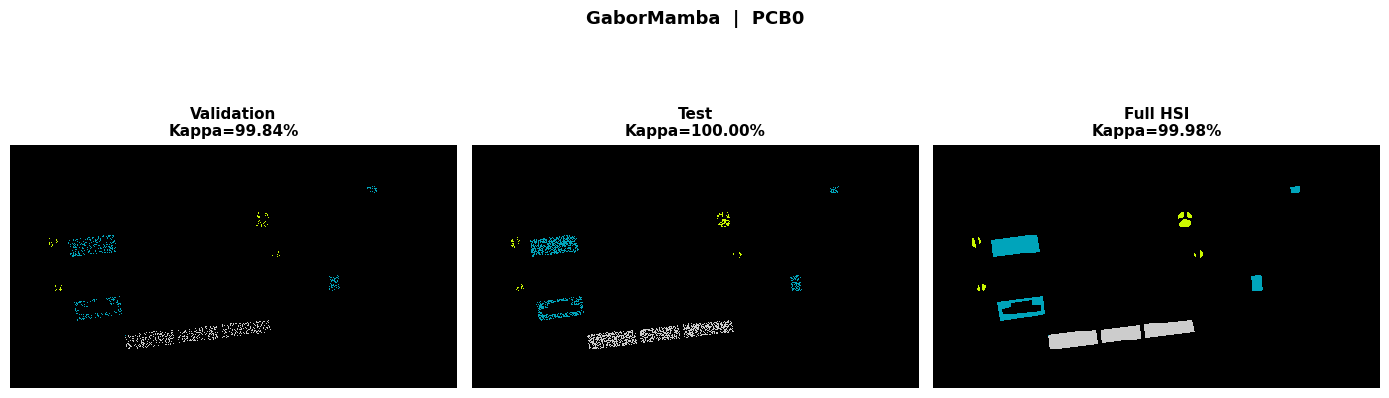

  ✅ Map : PCBDataset_PCB0_GaborMamba_Predicted_GTs.png


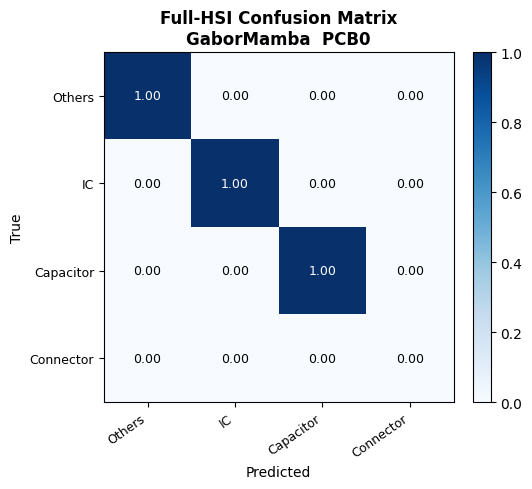

  ✅ CM  : PCBDataset_PCB0_GaborMamba_confusion.png

  ───────────────────────────────────────────────────────
  Model : CNN2D_AttGCN  |  PCB0
  ───────────────────────────────────────────────────────
Model: "CNN2D_AttGCN"
________________________________________________________________________________
 Layer (type)           Output Shape            Param   Connected to            
                                                 #                              
 input (InputLayer)     [(None, 8, 8, 15)]      0       []                      
                                                                                
 conv2d_80 (Conv2D)     (None, 8, 8, 8)         128     ['input[0][0]']         
                                                                                
 zero_padding2d_5 (Zer  (None, 10, 10, 8)       0       ['conv2d_80[0][0]']     
 oPadding2D)                                                                    
                                                 

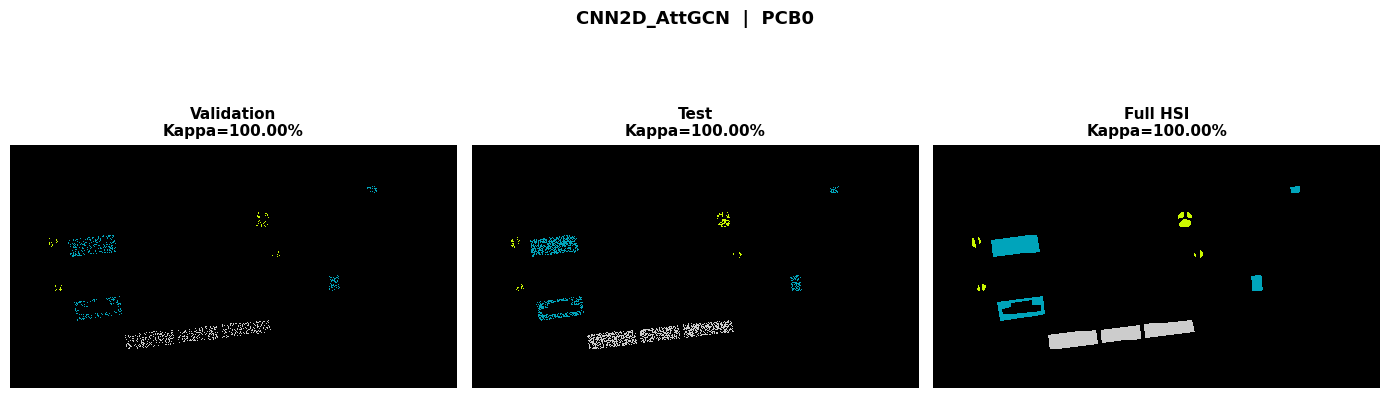

  ✅ Map : PCBDataset_PCB0_CNN2D_AttGCN_Predicted_GTs.png


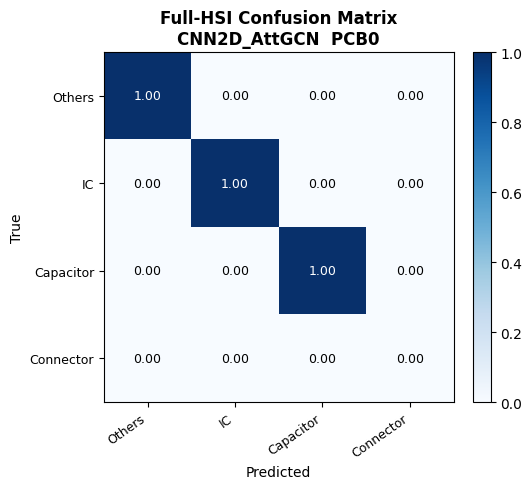

  ✅ CM  : PCBDataset_PCB0_CNN2D_AttGCN_confusion.png

######################################################################
# PCB2
######################################################################
  Tr:1698  Va:1700  Te:3400

  ───────────────────────────────────────────────────────
  Model : GaborMamba  |  PCB2
  ───────────────────────────────────────────────────────
Model: "GaborMamba"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 gabor_token_gen_6 (GaborTokenGen)  multiple                        8330        
                                                                                
 gabor_feature_gate_6 (GaborFeatur  multiple                        4160        
 eGate)                                                                         
                                                                                
 conv1d_temporal_encoder_6 (Conv1D 

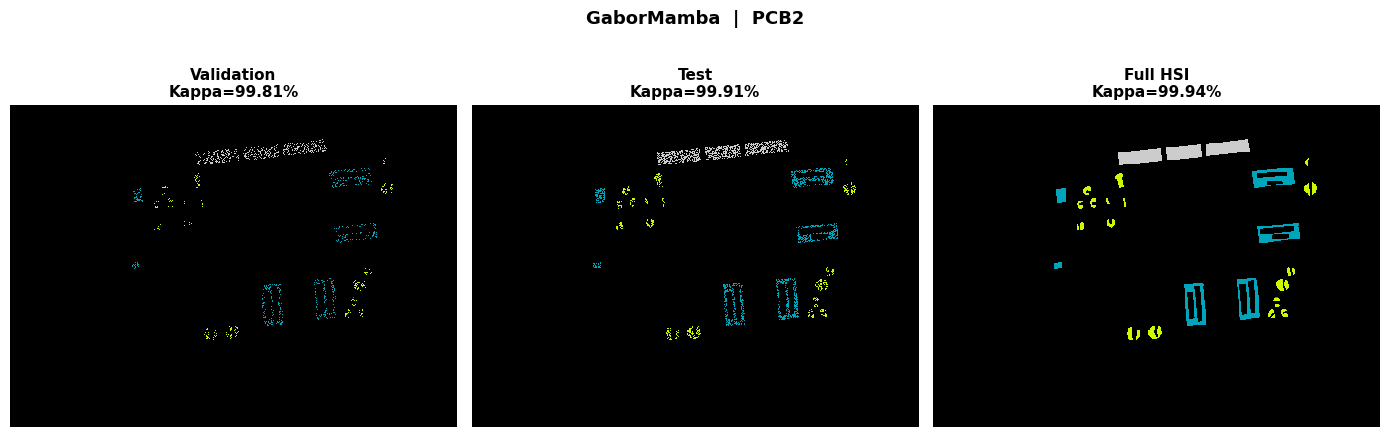

  ✅ Map : PCBDataset_PCB2_GaborMamba_Predicted_GTs.png


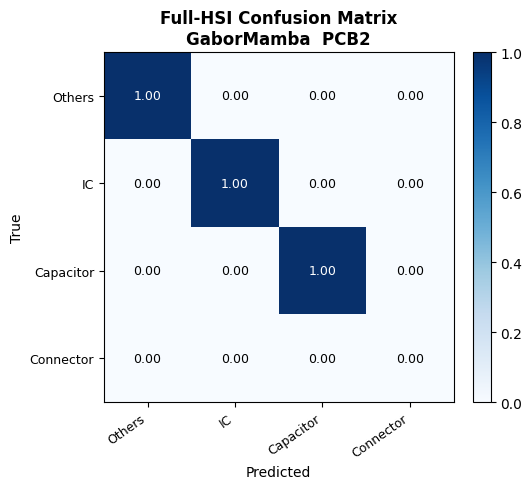

  ✅ CM  : PCBDataset_PCB2_GaborMamba_confusion.png

  ───────────────────────────────────────────────────────
  Model : CNN2D_AttGCN  |  PCB2
  ───────────────────────────────────────────────────────
Model: "CNN2D_AttGCN"
________________________________________________________________________________
 Layer (type)           Output Shape            Param   Connected to            
                                                 #                              
 input (InputLayer)     [(None, 8, 8, 15)]      0       []                      
                                                                                
 conv2d_95 (Conv2D)     (None, 8, 8, 8)         128     ['input[0][0]']         
                                                                                
 zero_padding2d_6 (Zer  (None, 10, 10, 8)       0       ['conv2d_95[0][0]']     
 oPadding2D)                                                                    
                                                 

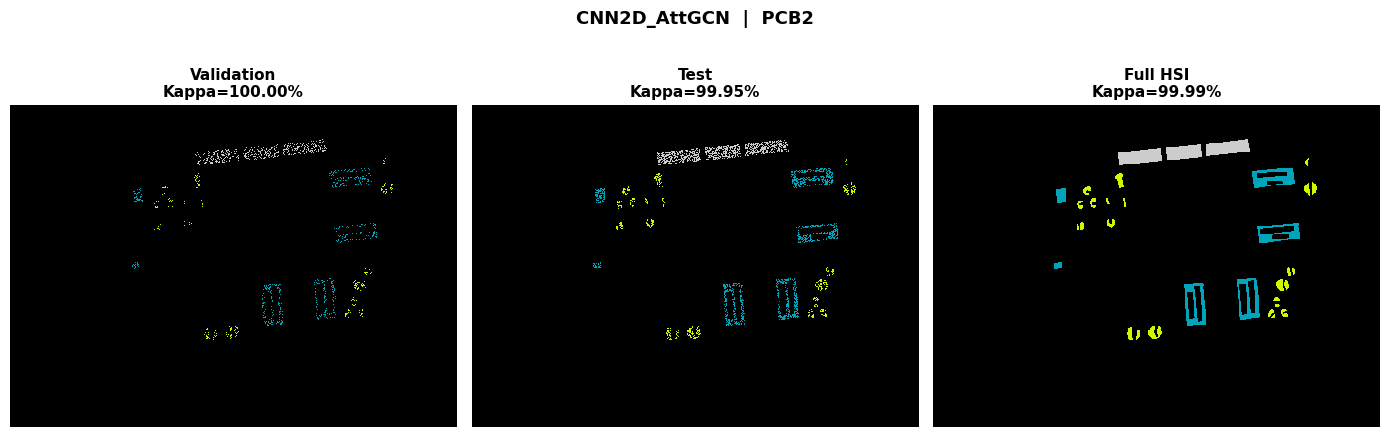

  ✅ Map : PCBDataset_PCB2_CNN2D_AttGCN_Predicted_GTs.png


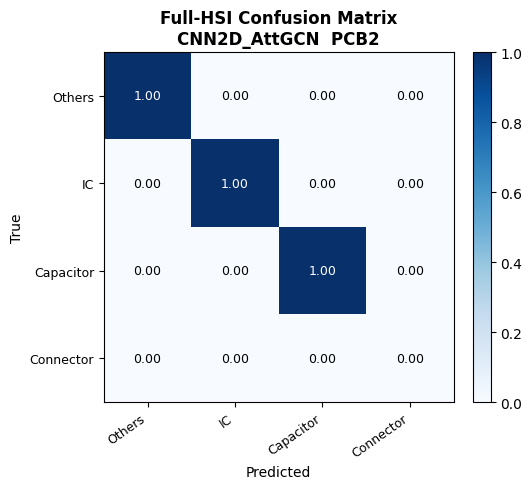

  ✅ CM  : PCBDataset_PCB2_CNN2D_AttGCN_confusion.png

######################################################################
# PCB17
######################################################################
  Tr:1568  Va:1569  Te:3140

  ───────────────────────────────────────────────────────
  Model : GaborMamba  |  PCB17
  ───────────────────────────────────────────────────────
Model: "GaborMamba"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 gabor_token_gen_7 (GaborTokenGen)  multiple                        8330        
                                                                                
 gabor_feature_gate_7 (GaborFeatur  multiple                        4160        
 eGate)                                                                         
                                                                                
 conv1d_temporal_encoder_7 (Conv1

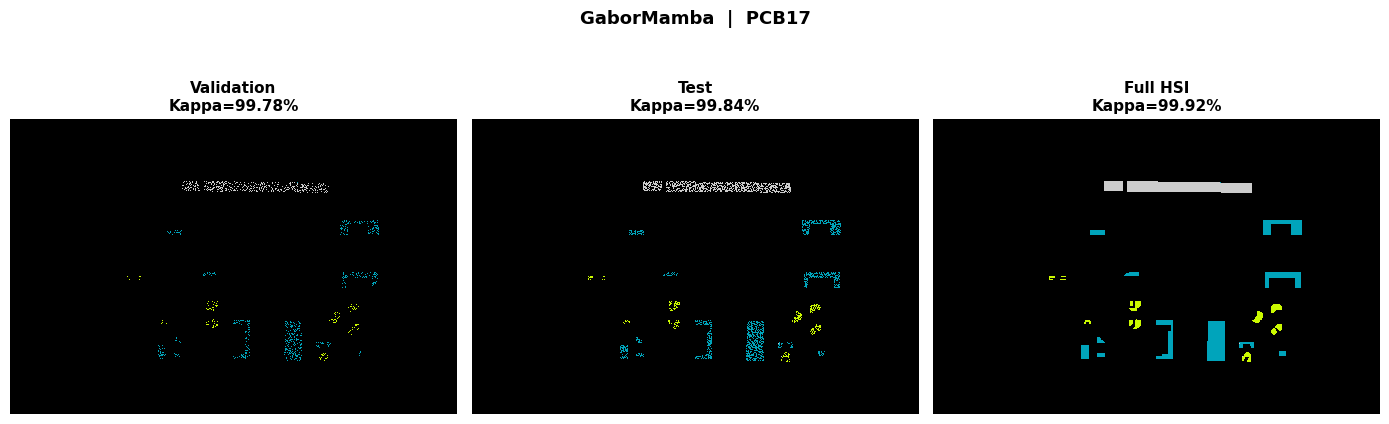

  ✅ Map : PCBDataset_PCB17_GaborMamba_Predicted_GTs.png


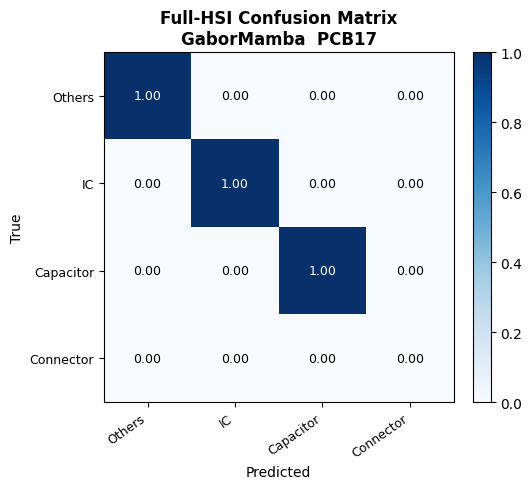

  ✅ CM  : PCBDataset_PCB17_GaborMamba_confusion.png

  ───────────────────────────────────────────────────────
  Model : CNN2D_AttGCN  |  PCB17
  ───────────────────────────────────────────────────────
Model: "CNN2D_AttGCN"
________________________________________________________________________________
 Layer (type)           Output Shape            Param   Connected to            
                                                 #                              
 input (InputLayer)     [(None, 8, 8, 15)]      0       []                      
                                                                                
 conv2d_110 (Conv2D)    (None, 8, 8, 8)         128     ['input[0][0]']         
                                                                                
 zero_padding2d_7 (Zer  (None, 10, 10, 8)       0       ['conv2d_110[0][0]']    
 oPadding2D)                                                                    
                                               

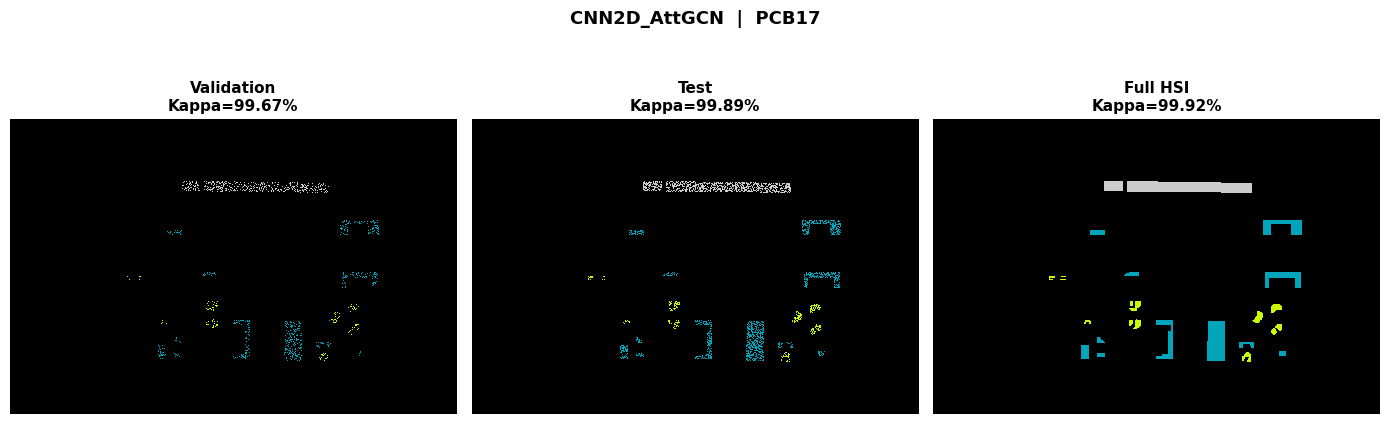

  ✅ Map : PCBDataset_PCB17_CNN2D_AttGCN_Predicted_GTs.png


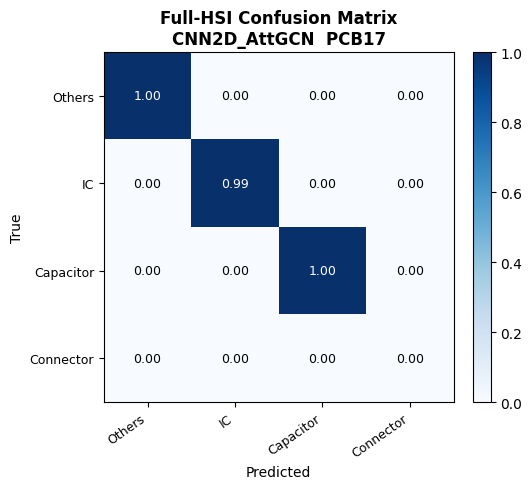

  ✅ CM  : PCBDataset_PCB17_CNN2D_AttGCN_confusion.png

######################################################################
# PCB27
######################################################################
  Tr:3262  Va:3264  Te:6527

  ───────────────────────────────────────────────────────
  Model : GaborMamba  |  PCB27
  ───────────────────────────────────────────────────────
Model: "GaborMamba"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 gabor_token_gen_8 (GaborTokenGen)  multiple                        8330        
                                                                                
 gabor_feature_gate_8 (GaborFeatur  multiple                        4160        
 eGate)                                                                         
                                                                                
 conv1d_temporal_encoder_8 (Conv

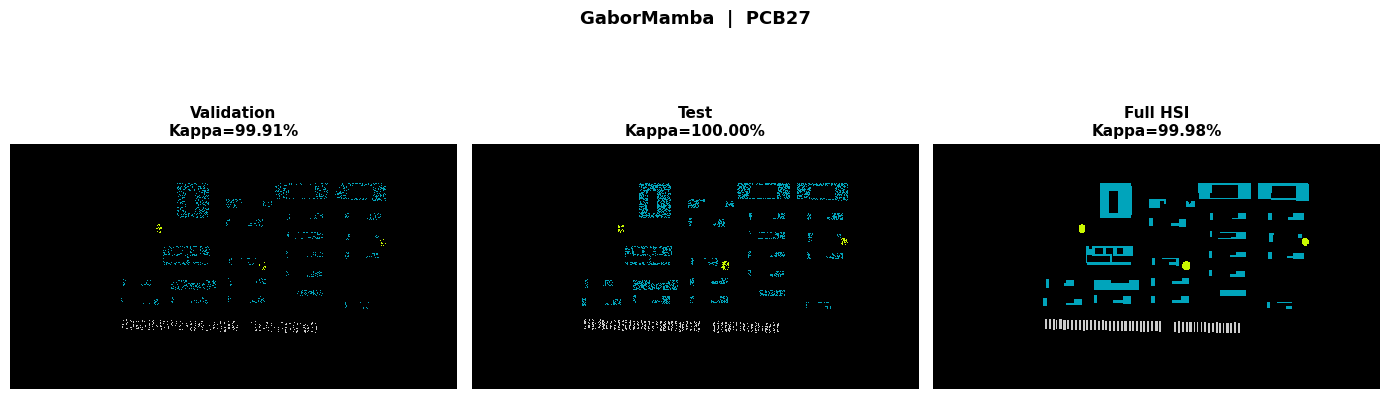

  ✅ Map : PCBDataset_PCB27_GaborMamba_Predicted_GTs.png


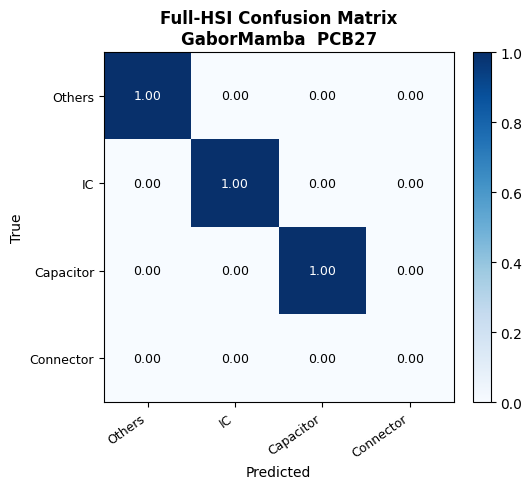

  ✅ CM  : PCBDataset_PCB27_GaborMamba_confusion.png

  ───────────────────────────────────────────────────────
  Model : CNN2D_AttGCN  |  PCB27
  ───────────────────────────────────────────────────────
Model: "CNN2D_AttGCN"
________________________________________________________________________________
 Layer (type)           Output Shape            Param   Connected to            
                                                 #                              
 input (InputLayer)     [(None, 8, 8, 15)]      0       []                      
                                                                                
 conv2d_125 (Conv2D)    (None, 8, 8, 8)         128     ['input[0][0]']         
                                                                                
 zero_padding2d_8 (Zer  (None, 10, 10, 8)       0       ['conv2d_125[0][0]']    
 oPadding2D)                                                                    
                                               

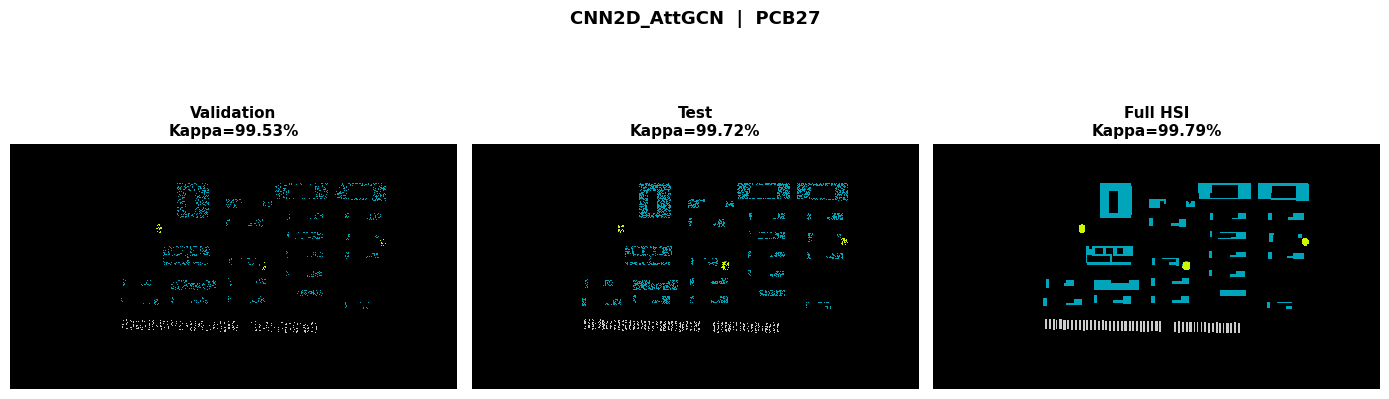

  ✅ Map : PCBDataset_PCB27_CNN2D_AttGCN_Predicted_GTs.png


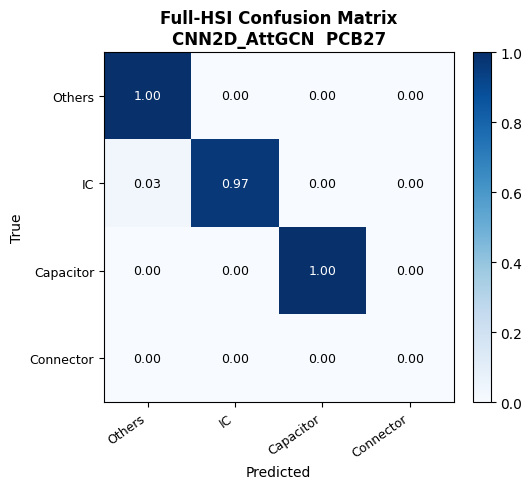

  ✅ CM  : PCBDataset_PCB27_CNN2D_AttGCN_confusion.png

######################################################################
# PCB52
######################################################################
  Tr:748  Va:749  Te:1499

  ───────────────────────────────────────────────────────
  Model : GaborMamba  |  PCB52
  ───────────────────────────────────────────────────────
Model: "GaborMamba"
________________________________________________________________________________
 Layer (type)                       Output Shape                    Param #     
 gabor_token_gen_9 (GaborTokenGen)  multiple                        8330        
                                                                                
 gabor_feature_gate_9 (GaborFeatur  multiple                        4160        
 eGate)                                                                         
                                                                                
 conv1d_temporal_encoder_9 (Conv1D

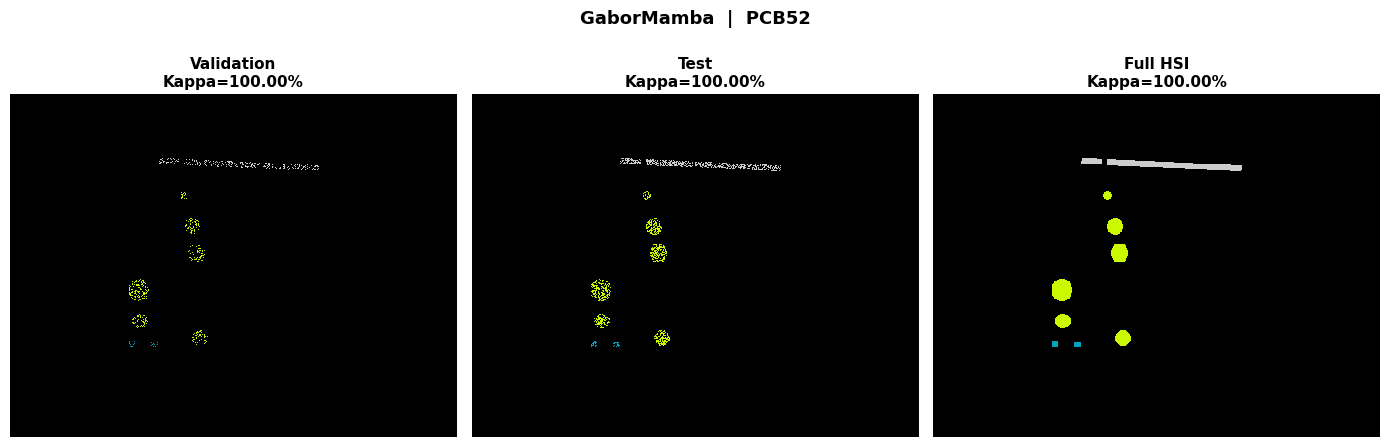

  ✅ Map : PCBDataset_PCB52_GaborMamba_Predicted_GTs.png


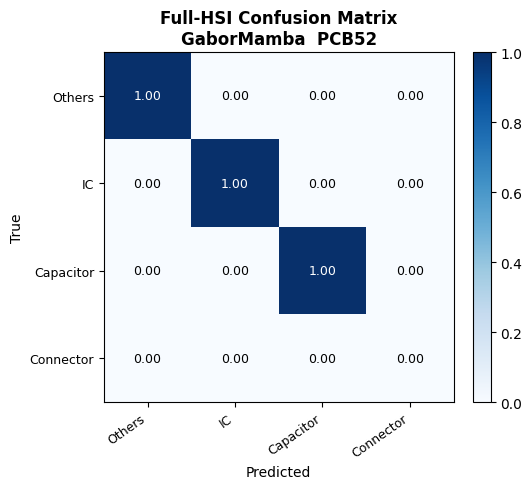

  ✅ CM  : PCBDataset_PCB52_GaborMamba_confusion.png

  ───────────────────────────────────────────────────────
  Model : CNN2D_AttGCN  |  PCB52
  ───────────────────────────────────────────────────────
Model: "CNN2D_AttGCN"
________________________________________________________________________________
 Layer (type)           Output Shape            Param   Connected to            
                                                 #                              
 input (InputLayer)     [(None, 8, 8, 15)]      0       []                      
                                                                                
 conv2d_140 (Conv2D)    (None, 8, 8, 8)         128     ['input[0][0]']         
                                                                                
 zero_padding2d_9 (Zer  (None, 10, 10, 8)       0       ['conv2d_140[0][0]']    
 oPadding2D)                                                                    
                                               

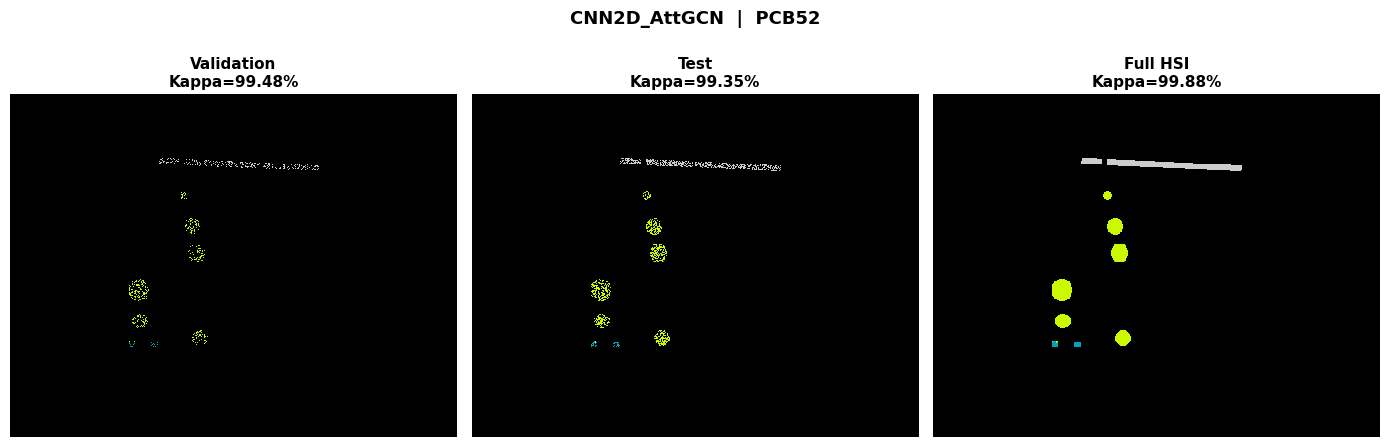

  ✅ Map : PCBDataset_PCB52_CNN2D_AttGCN_Predicted_GTs.png


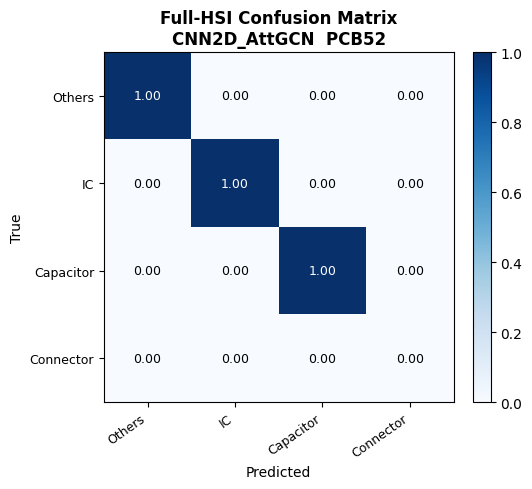

  ✅ CM  : PCBDataset_PCB52_CNN2D_AttGCN_confusion.png

✨ All PCBs complete.


In [ ]:
all_histories = {}   # {pcb_tag: {model_name: history}}
all_metrics   = {}   # {pcb_tag: [metrics_dict, ...]}

for meta in pcb_data_list:
    pcb_index = meta['pcb_index']
    pcb_tag   = f"PCB{pcb_index}"

    print(f"\n{'#'*70}")
    print(f"# {pcb_tag}")
    print(f"{'#'*70}")
    print(f"  Tr:{len(meta['TrInd'])}  "
          f"Va:{len(meta['VaInd'])}  "
          f"Te:{len(meta['TeInd'])}")

    all_histories[pcb_tag] = {}
    all_metrics[pcb_tag]   = []

    for model_name_str, model_fn in model_fns:
        try:
            history, metrics = train_and_evaluate_model(
                model_fn        = model_fn,
                model_name_str  = model_name_str,
                Tr              = meta['Tr'],
                TrC             = meta['TrC'],
                Va              = meta['Va'],
                VaC             = meta['VaC'],
                Te              = meta['Te'],
                TeC             = meta['TeC'],
                CRDHSI          = meta['CRDHSI'],
                GT              = meta['GT'],
                flattened       = meta['flattened'],
                val_matrix      = meta['val_matrix'],
                VaInd           = meta['VaInd'],
                test_matrix     = meta['test_matrix'],
                TeInd           = meta['TeInd'],
                pcb_tag         = pcb_tag,
            )
            all_histories[pcb_tag][model_name_str] = history
            all_metrics[pcb_tag].append(metrics)

        except Exception as e:
            print(f"\n  ❌ {model_name_str} FAILED: {e}")
            traceback.print_exc()

        gc.collect()

    gc.collect()

print("\n✨ All PCBs complete.")

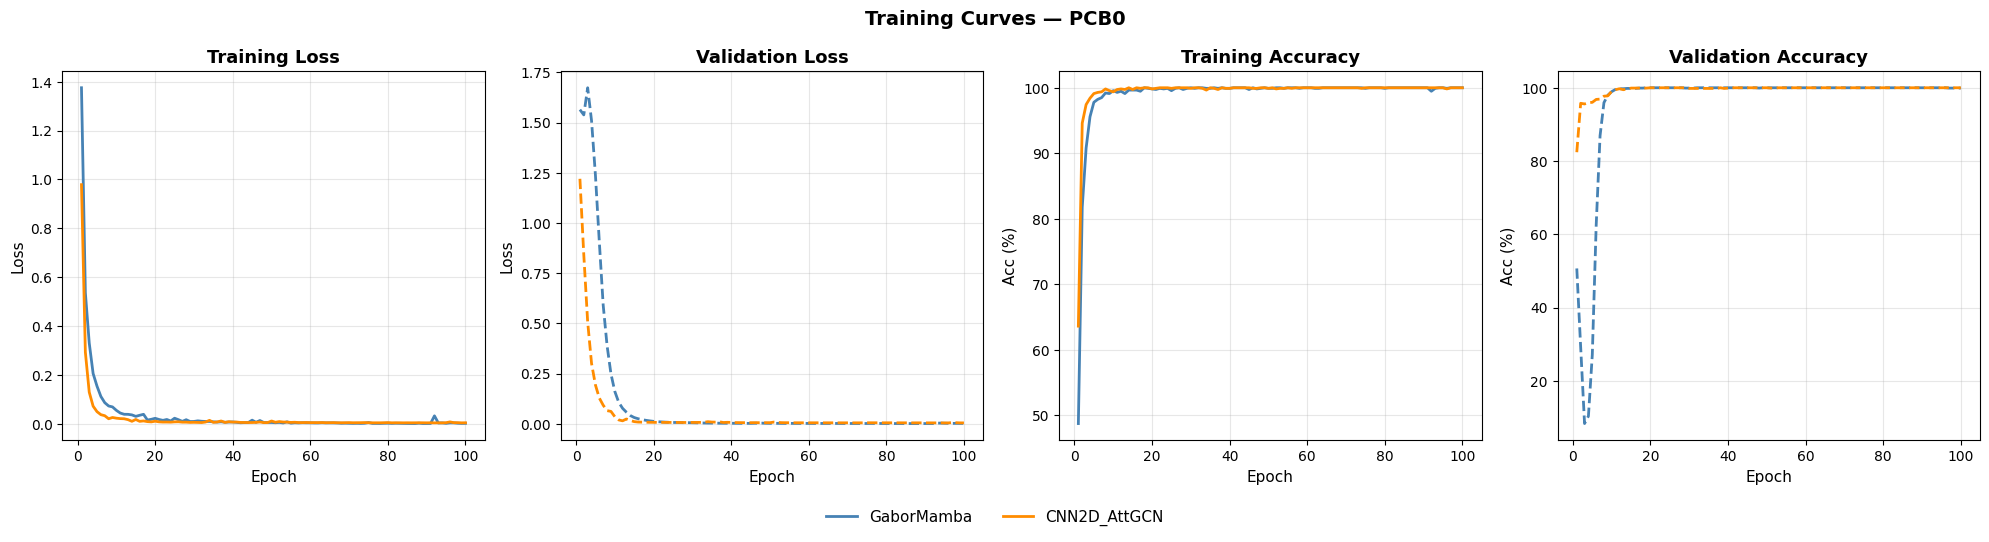

✅ PCBDataset_PCB0_training_curves.png


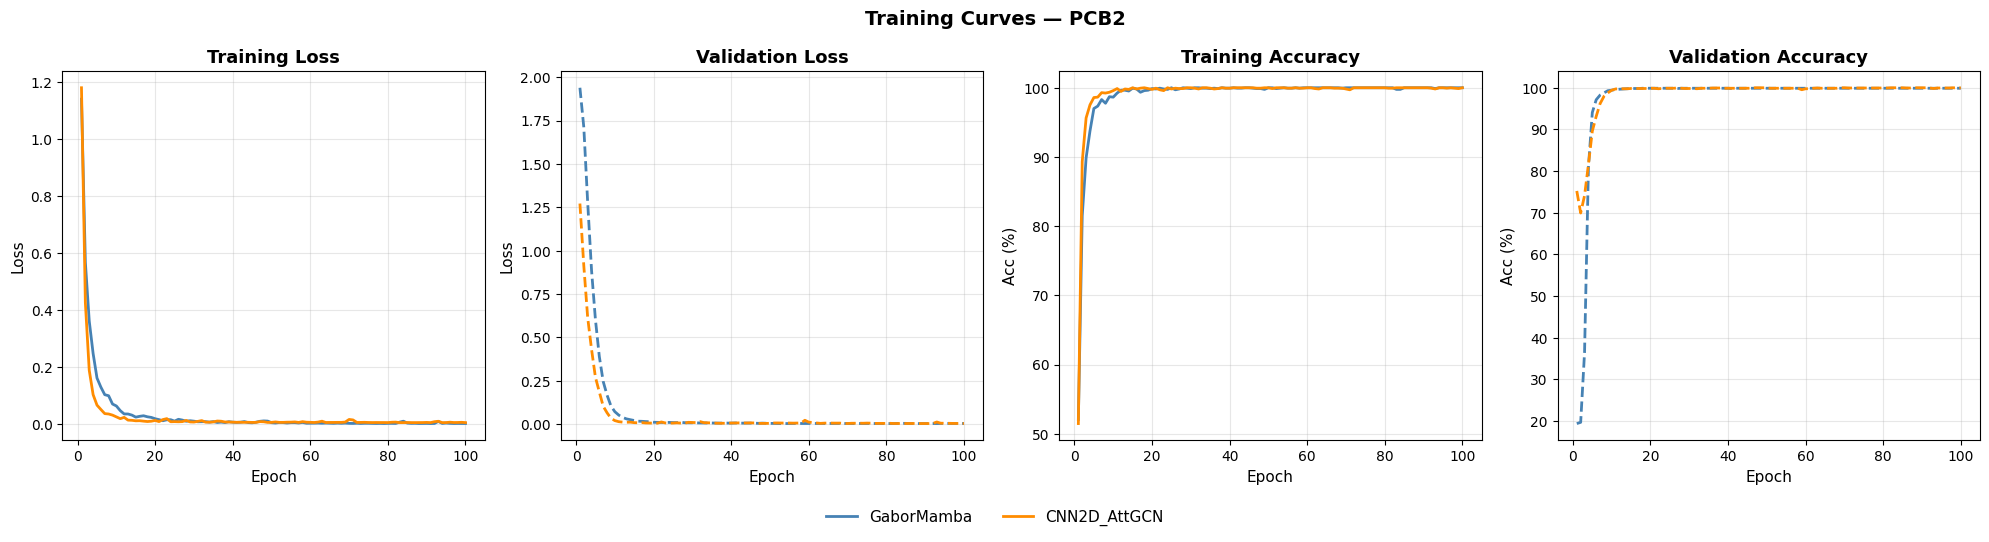

✅ PCBDataset_PCB2_training_curves.png


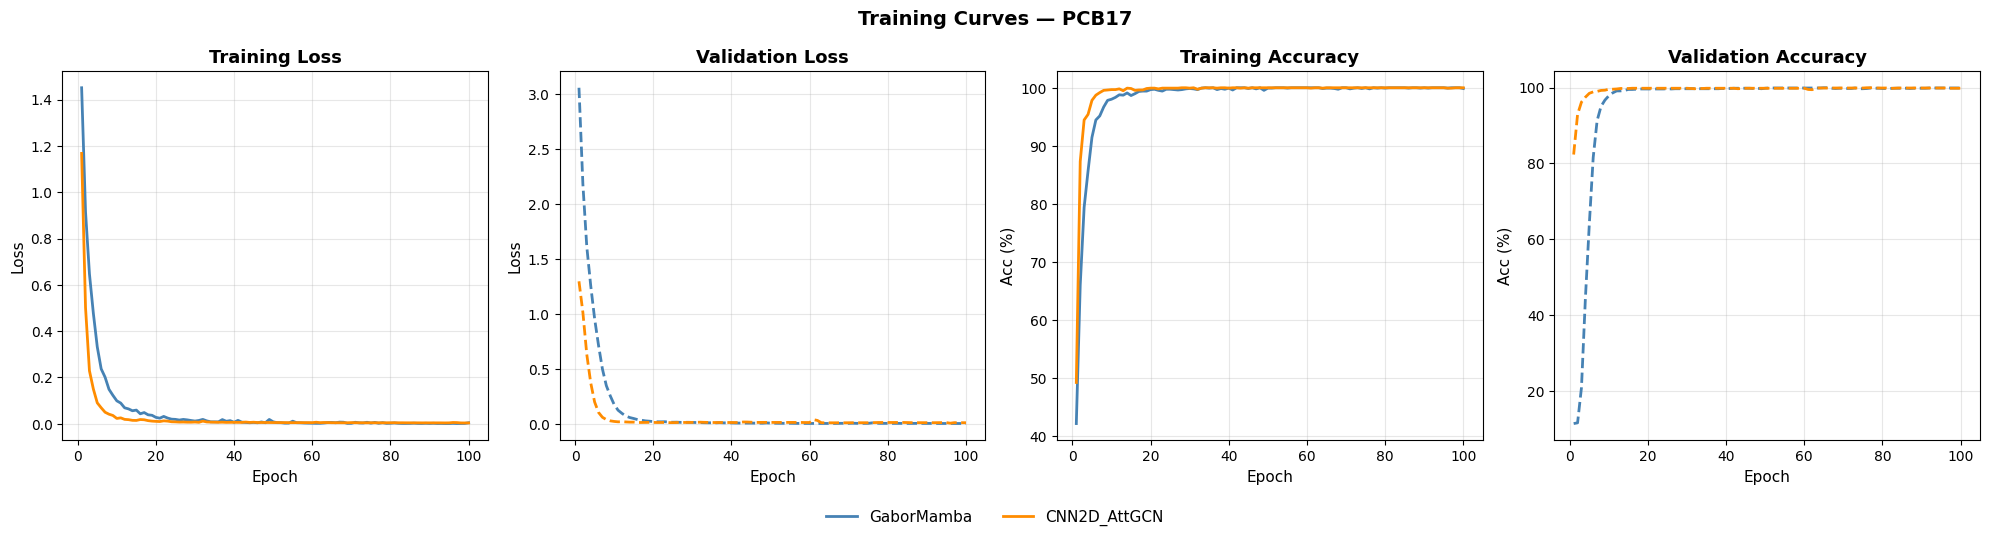

✅ PCBDataset_PCB17_training_curves.png


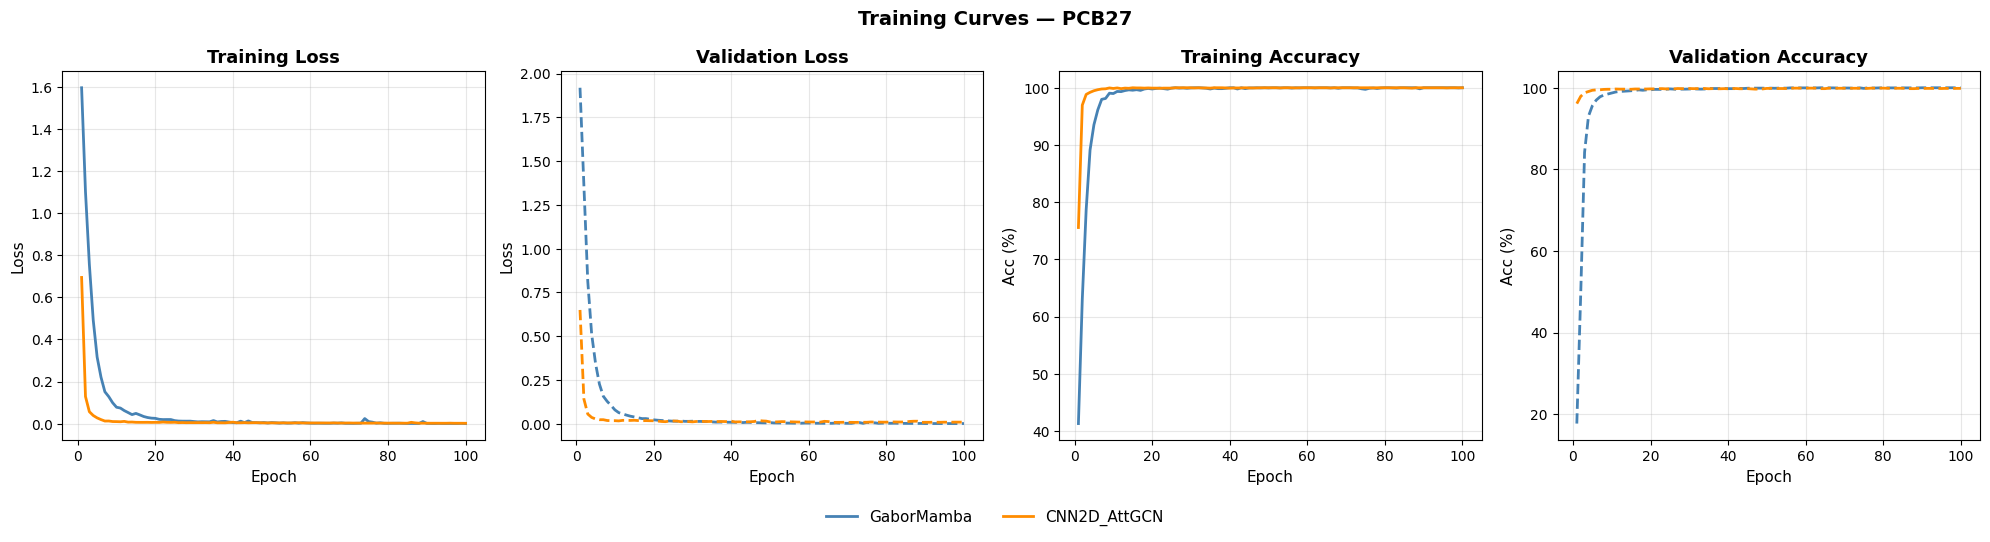

✅ PCBDataset_PCB27_training_curves.png


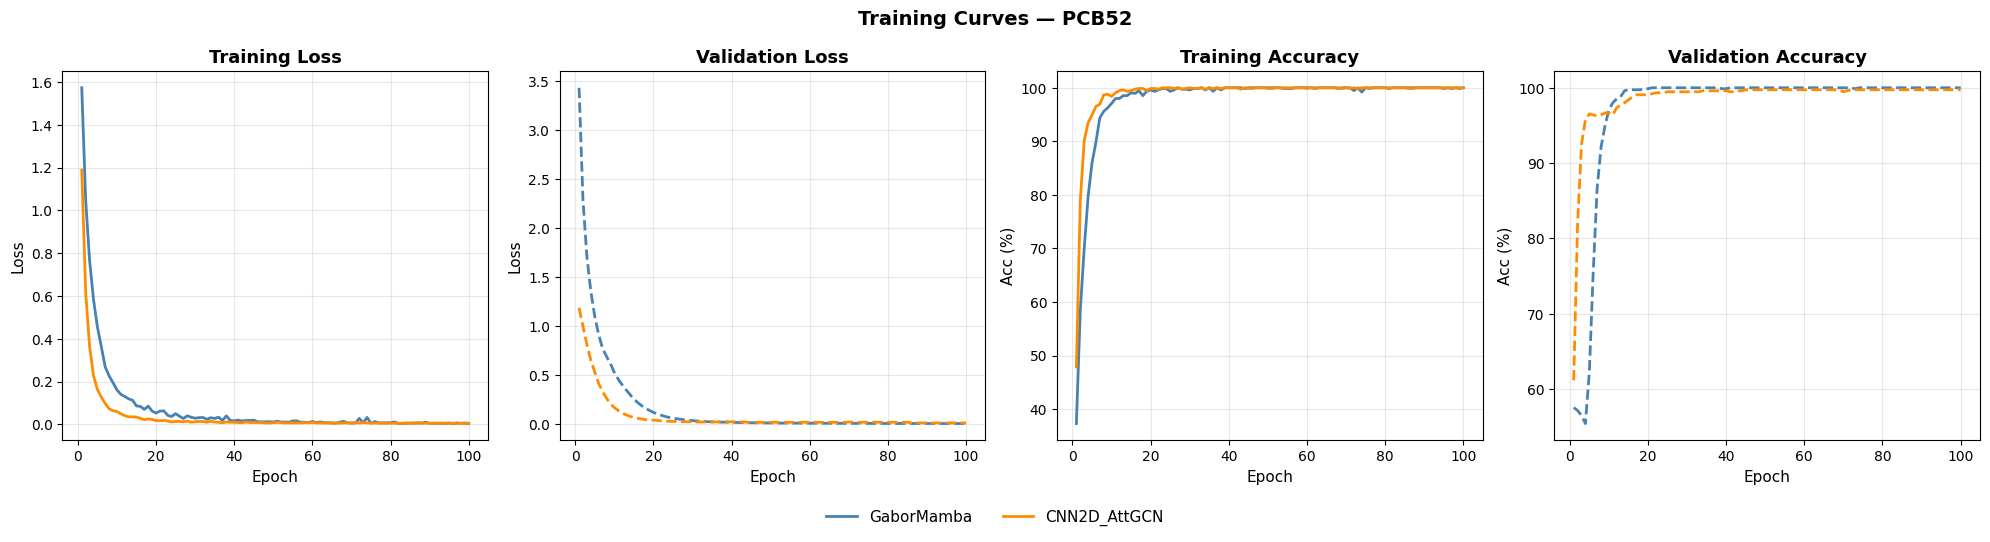

✅ PCBDataset_PCB52_training_curves.png


In [ ]:
for pcb_tag, hists in all_histories.items():
    if not hists:
        continue

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    legend_labels = []
    colors        = ['steelblue', 'darkorange']

    for i, (model_name, history) in enumerate(hists.items()):
        ep  = range(1, len(history.history['loss']) + 1)
        clr = colors[i % len(colors)]
        axs[0].plot(ep, history.history['loss'],
                    lw=2, color=clr)
        axs[1].plot(ep, history.history['val_loss'],
                    lw=2, color=clr, ls='--')
        axs[2].plot(ep, [v*100 for v in history.history['accuracy']],
                    lw=2, color=clr)
        axs[3].plot(ep, [v*100 for v in history.history['val_accuracy']],
                    lw=2, color=clr, ls='--')
        legend_labels.append(model_name)

    for ax, title, ylabel in zip(axs,
        ['Training Loss',   'Validation Loss',
         'Training Accuracy','Validation Accuracy'],
        ['Loss', 'Loss', 'Acc (%)', 'Acc (%)']):
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.grid(True, alpha=0.3)

    fig.legend(legend_labels, loc='lower center', ncol=2,
               fontsize=11, bbox_to_anchor=(0.5, -0.08), frameon=False)
    fig.suptitle(f"Training Curves — {pcb_tag}",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f"{HSID}_{pcb_tag}_training_curves.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"✅ {fname}")


PCB0 — Results Summary
                 Va_OA   Va_AA      Va_K  Te_OA  Te_AA   Te_K    HSI_OA   HSI_AA     HSI_K   Params
model                                                                                              
GaborMamba     99.9116  74.957   99.8404  100.0   75.0  100.0   99.9993  74.9893   99.9806   221774
CNN2D_AttGCN  100.0000  75.000  100.0000  100.0   75.0  100.0  100.0000  75.0000  100.0000  1185459
✅ PCBDataset_PCB0_summary.csv


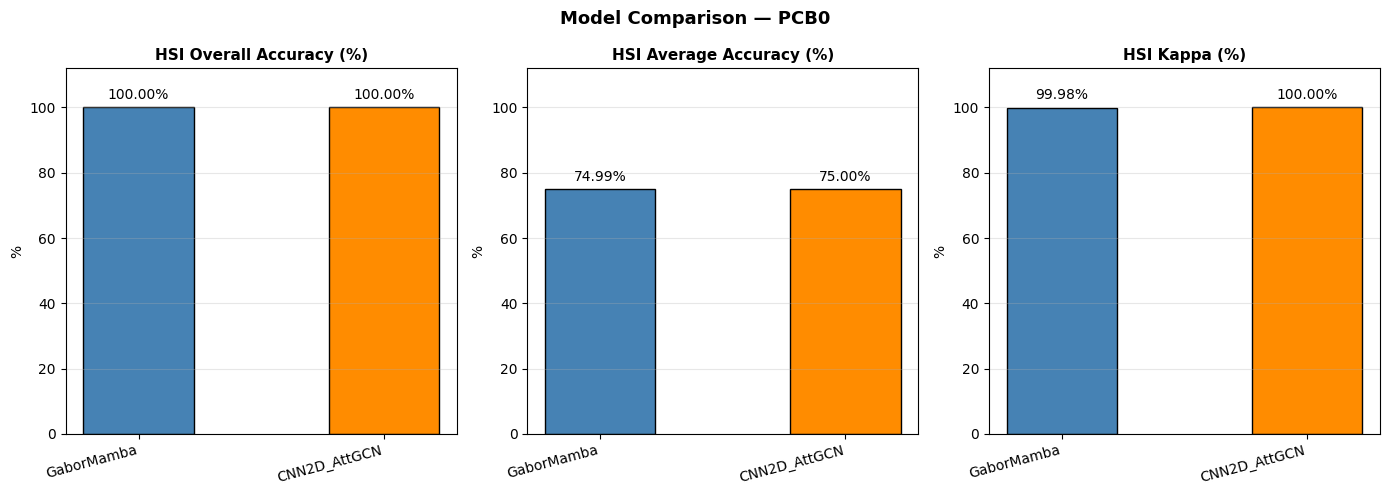

✅ PCBDataset_PCB0_model_comparison.png

PCB2 — Results Summary
                 Va_OA    Va_AA      Va_K    Te_OA    Te_AA     Te_K   HSI_OA   HSI_AA    HSI_K   Params
model                                                                                                   
GaborMamba     99.8824  74.8485   99.8134  99.9412  74.9241  99.9067  99.9982  74.9241  99.9447   221774
CNN2D_AttGCN  100.0000  75.0000  100.0000  99.9706  74.9841  99.9534  99.9996  74.9999  99.9862  1185459
✅ PCBDataset_PCB2_summary.csv


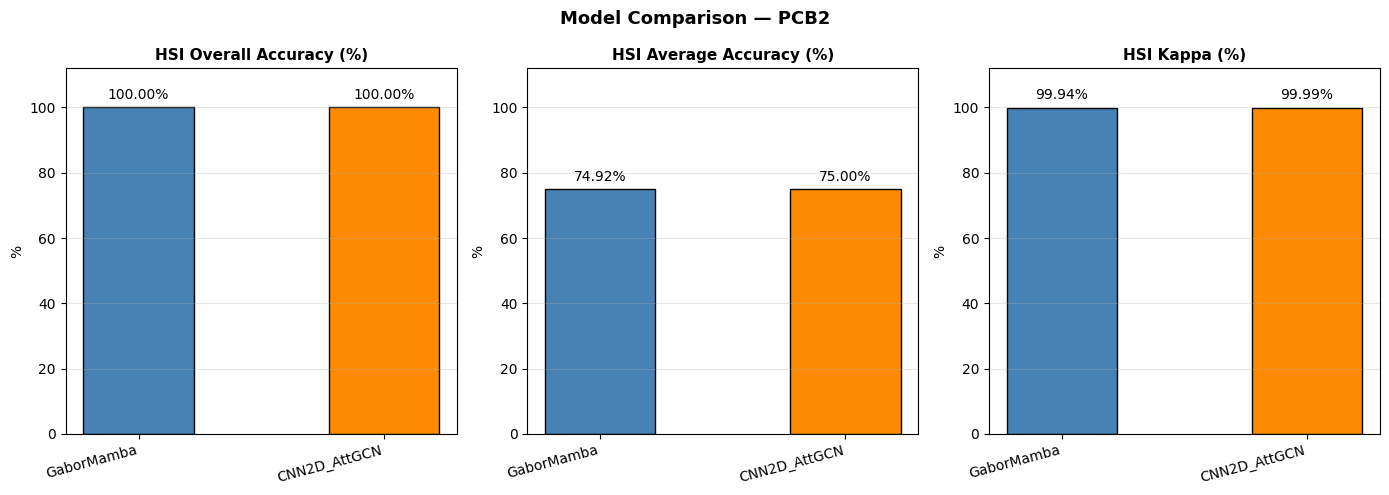

✅ PCBDataset_PCB2_model_comparison.png

PCB17 — Results Summary
                Va_OA    Va_AA     Va_K    Te_OA    Te_AA     Te_K   HSI_OA   HSI_AA   HSI_K   Params
model                                                                                                
GaborMamba    99.8725  74.9141  99.7819  99.9045  74.8996  99.8366  99.9976  74.9435  99.917   221774
CNN2D_AttGCN  99.8088  74.6912  99.6728  99.9363  74.8611  99.8910  99.9976  74.8608  99.917  1185459
✅ PCBDataset_PCB17_summary.csv


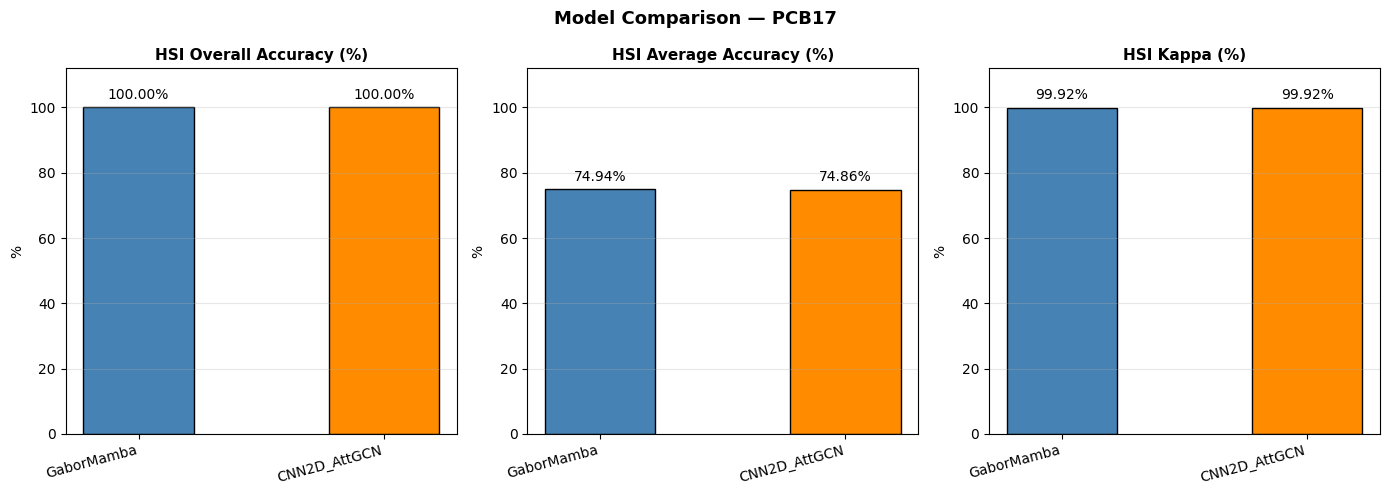

✅ PCBDataset_PCB17_model_comparison.png

PCB27 — Results Summary
                Va_OA    Va_AA     Va_K     Te_OA    Te_AA      Te_K   HSI_OA   HSI_AA    HSI_K   Params
model                                                                                                   
GaborMamba    99.9694  74.9904  99.9066  100.0000  75.0000  100.0000  99.9996  74.9999  99.9805   221774
CNN2D_AttGCN  99.8468  73.5465  99.5308   99.9081  74.1279   99.7187  99.9955  74.2006  99.7855  1185459
✅ PCBDataset_PCB27_summary.csv


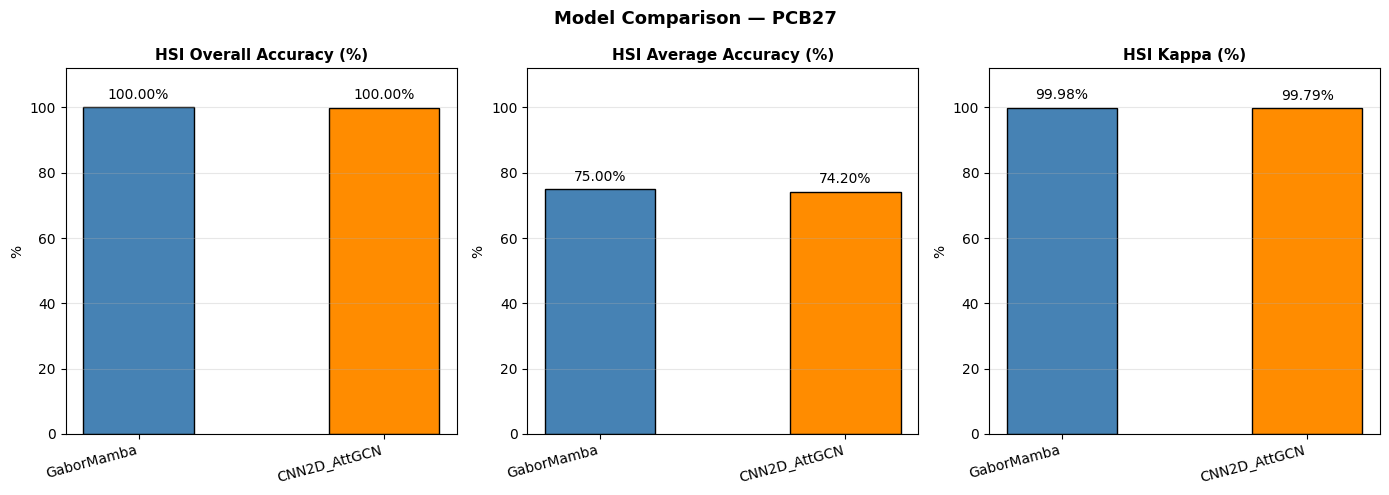

✅ PCBDataset_PCB27_model_comparison.png

PCB52 — Results Summary
                Va_OA    Va_AA      Va_K     Te_OA    Te_AA      Te_K    HSI_OA   HSI_AA    HSI_K   Params
model                                                                                                     
GaborMamba    100.000  75.0000  100.0000  100.0000  75.0000  100.0000  100.0000  75.0000  100.000   221774
CNN2D_AttGCN   99.733  72.9167   99.4788   99.6664  73.4114   99.3511   99.9966  74.9704   99.878  1185459
✅ PCBDataset_PCB52_summary.csv


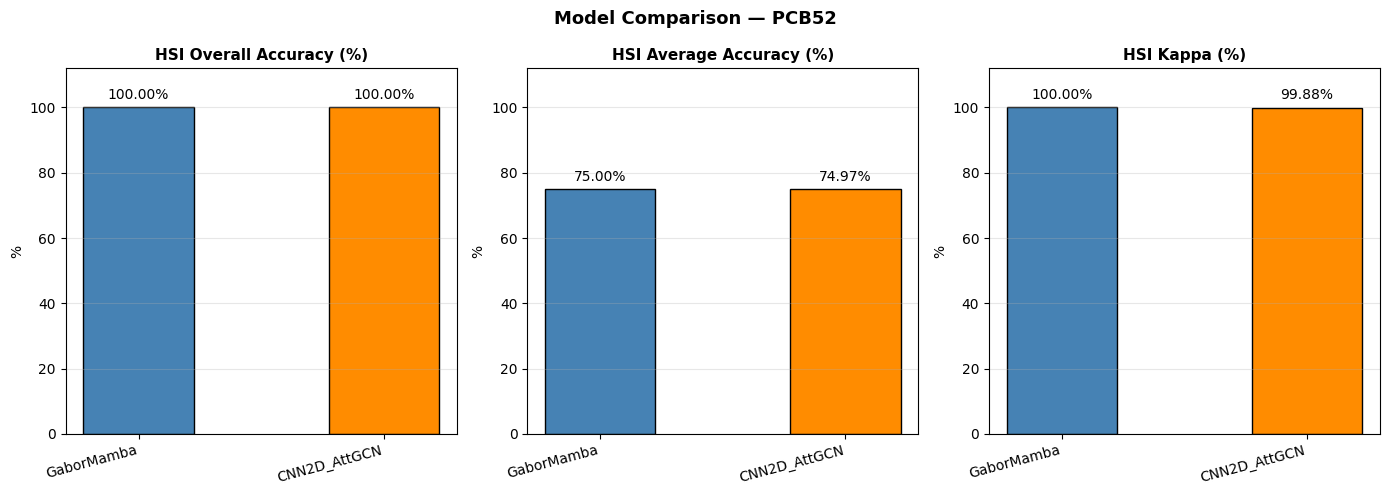

✅ PCBDataset_PCB52_model_comparison.png


In [ ]:
for pcb_tag, metrics_list in all_metrics.items():
    if not metrics_list:
        continue

    df = pd.DataFrame(metrics_list).set_index('model')

    print(f"\n{'='*60}")
    print(f"{pcb_tag} — Results Summary")
    print(f"{'='*60}")
    print(df.to_string())

    # Save summary CSV
    csv_path = f"{HSID}_{pcb_tag}_summary.csv"
    df.to_csv(csv_path)
    print(f"✅ {csv_path}")

    # Bar chart
    metrics_to_plot = [
        ('HSI_OA', 'HSI Overall Accuracy (%)'),
        ('HSI_AA', 'HSI Average Accuracy (%)'),
        ('HSI_K',  'HSI Kappa (%)'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    colors = ['steelblue', 'darkorange']

    for ax, (col, title) in zip(axes, metrics_to_plot):
        bars = ax.bar(df.index, df[col],
                      color=colors[:len(df)],
                      edgecolor='black', width=0.45)
        ax.bar_label(bars,
                     labels=[f"{v:.2f}%" for v in df[col]],
                     padding=4, fontsize=10)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_ylabel('%')
        ax.set_ylim(0, 112)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticklabels(df.index, rotation=15, ha='right', fontsize=10)

    fig.suptitle(f"Model Comparison — {pcb_tag}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f"{HSID}_{pcb_tag}_model_comparison.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()
    print(f"✅ {fname}")